In [12]:
import tenpy
# from tenpy.models.model import CouplingMPOModel
# from tenpy.networks.site import SpinHalfFermionSite
# from tenpy.networks.mps import MPS
# from tenpy.algorithms import dmrg as tenpy_dmrg
import sys
sys.path.append('..')

# import importlib
# # importlib.reload(sys.modules['src'])
# importlib.reload(sys.modules['utils.bosonization'])
# importlib.reload(sys.modules['utils.slurmhelpers'])

from src.extendedHubbard import HubbardSpinDepV, run_idmrg
from utils.bosonization import ret_Vpm_crit, compute_Luttinger_parameter
from utils.slurmhelpers import ret_arr_for_taskid
import utils.io as io
import logging 
logging.basicConfig(level=logging.INFO)
import time
import numpy as np
import matplotlib.pyplot as plt
import os
import re, glob
import pandas as pd
print(f"TeNPy version: {tenpy.__version__}")
DATA_ROOT = '../../data/iDMRG/'


TeNPy version: 1.1.0


In [ ]:
REQ_DATA = 't_1.00_U_0.10_Vpp_0.800'
PATH_TO_REQ_DATA = os.path.join(DATA_ROOT, REQ_DATA)
file_list = [os.path.join(PATH_TO_REQ_DATA,f) for f in os.listdir(PATH_TO_REQ_DATA) if "chimax_100" in f]


['../../data/iDMRG/t_1.00_U_0.10_Vpp_0.800/Vpm_3.8500_chimax_100.h5',
 '../../data/iDMRG/t_1.00_U_0.10_Vpp_0.800/Vpm_2.8000_chimax_100.h5',
 '../../data/iDMRG/t_1.00_U_0.10_Vpp_0.800/Vpm_3.9000_chimax_100.h5',
 '../../data/iDMRG/t_1.00_U_0.10_Vpp_0.800/Vpm_3.4000_chimax_100.h5',
 '../../data/iDMRG/t_1.00_U_0.10_Vpp_0.800/Vpm_4.1000_chimax_100.h5',
 '../../data/iDMRG/t_1.00_U_0.10_Vpp_0.800/Vpm_4.0000_chimax_100.h5',
 '../../data/iDMRG/t_1.00_U_0.10_Vpp_0.800/Vpm_3.8000_chimax_100.h5',
 '../../data/iDMRG/t_1.00_U_0.10_Vpp_0.800/Vpm_3.9500_chimax_100.h5',
 '../../data/iDMRG/t_1.00_U_0.10_Vpp_0.800/Vpm_4.2000_chimax_100.h5',
 '../../data/iDMRG/t_1.00_U_0.10_Vpp_0.800/Vpm_3.7000_chimax_100.h5']

In [59]:
def atomic_action(file): 
    psi, metadata = io.load_mps_with_metadata(file)
    model_params = metadata['model_params']
    row_dict = {
        'psi' : psi, 
        'dV' : model_params['Vpm'] - model_params['Vpp'], 
        'mean_Sz' : metadata['mean_Sz'], 
        'mean_fill' : metadata['mean_fill'],
    }
    return row_dict
    
df = pd.DataFrame([atomic_action(f) for f in file_list])
df = df.sort_values('dV')
df.head()


,psi,dV,mean_Sz,mean_fill
1,"MPS, L=2, bc='infinite'.\nchi: [100, 100]\nsit...",2.00,-3.834845e-14,0.537152
3,"MPS, L=2, bc='infinite'.\nchi: [100, 100]\nsit...",2.60,-9.118812e-14,0.494708
9,"MPS, L=2, bc='infinite'.\nchi: [100, 100]\nsit...",2.90,3.320430e-12,0.474461
6,"MPS, L=2, bc='infinite'.\nchi: [100, 100]\nsit...",3.00,-2.086249e-01,0.417250
0,"MPS, L=2, bc='infinite'.\nchi: [100, 100]\nsit...",3.05,2.483487e-13,0.464278


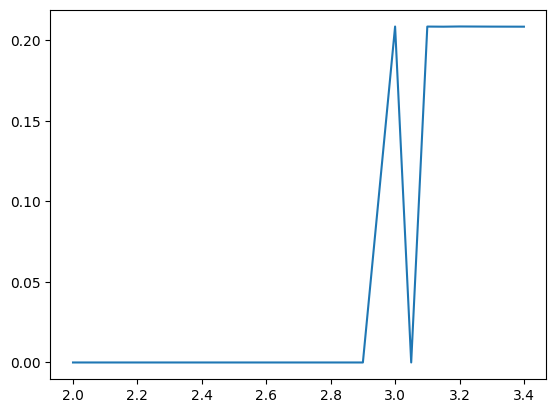

In [61]:
plt.plot(df['dV'], np.abs(df['mean_Sz']))
